ESERCIZIO 1 DEL 20/05

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import rfftn,fftfreq,rfftfreq

In [2]:
#box size in mpc/h
L=1000 
volume=L**3
#number of grid points
n_points=100000
density=n_points/volume
print("Density: ",density)

#create particles
x,y,z=np.random.uniform(0,L,size=(3,n_points))  #campo densità è discreto e non ho direz preferenziale, no segnale clustering, 
#ma per Pk devo metterlo su griglia e ci sono diversi modi di farlo; 1 modo: divido vol in celle e vedo quanti punti in ciascuna cella

Density:  0.0001


In [3]:
n_cells=64 #è un nostro parametro, def fino  ache scala voglio misuare Pk, meglio se è multiplo di 2 per dopo
cell_size=L/n_cells
print("Cell size: ",cell_size) #mpc/h

#compute the mean density
cell_mean_density=n_points/n_cells**3
print("Mean density in the cell: ",cell_mean_density) #mpc**-3/h**3

#create density grid with histogramdd
grid,edges=np.histogramdd((x,y,z),bins=(n_cells,n_cells,n_cells),range=((0,L),(0,L),(0,L)))

#compute the density field
density_field=(grid-cell_mean_density)/cell_mean_density 

Cell size:  15.625
Mean density in the cell:  0.3814697265625


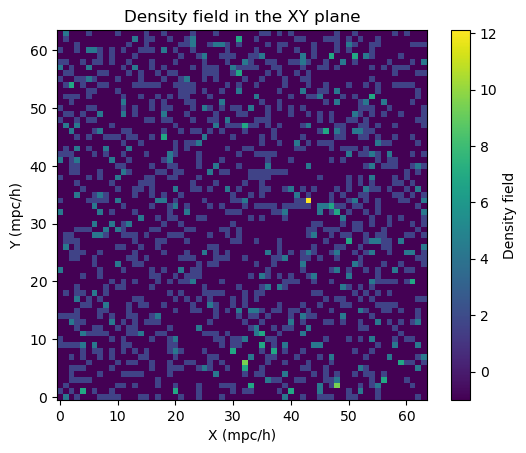

In [4]:
plt.imshow(density_field[:,:,0],origin='lower',cmap='viridis')
plt.colorbar(label='Density field')
plt.title('Density field in the XY plane')
plt.xlabel('X (mpc/h)')
plt.ylabel('Y (mpc/h)')
plt.show()

In [5]:
#compute the delta in fourier space
delta_k=rfftn(density_field)/n_cells**3  #normmalizzo per il number di celle  
#è oggetto grande: (64,64,33) e vale che f(-k)=f*(k) e f(k)=f(-k) (coniugato)

#create the k grid
kF=2*np.pi/L  #fondamental frequency in mpc**-1/h
H=L/n_cells
kN=np.pi/H   #Nyquist frequency in mpc**-1/h
kx=fftfreq(n_cells,d=1/n_cells)*kF
ky=fftfreq(n_cells,d=1/n_cells)*kF
kz=rfftfreq(n_cells,d=1/n_cells)*kF

KX,KY,KZ=np.meshgrid(kx,ky,kz)
KK=np.sqrt(KX**2+KY**2+KZ**2)  

#fftfreq(n_cells,d=1/n_cells) 

In [6]:
#calcolo spettro di pot su griglia
pk_grid=delta_k*np.conjugate(delta_k)*volume  #metto il volume perchè non sono nel continuo ma nel discreto
#ora devo fare binning griglia per avere p(|k|)
#Binning
c=1
k_edges=np.arange(kF,kN,c*kF) 
k_bins=0.5*(k_edges[1:]+k_edges[:-1])
#print("k edges: ",k_edges)

/home/maddaba/anaconda3/envs/acc-env/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/maddaba/anaconda3/envs/acc-env/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


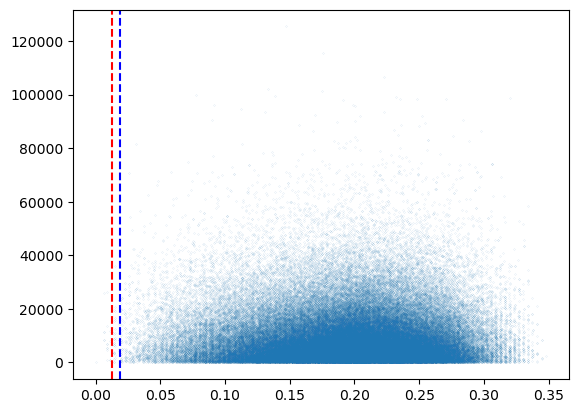

In [7]:
plt.plot(KK.flatten(),pk_grid.flatten(),'.',markersize=0.1)
plt.axvline(k_edges[1], color='red', linestyle='--', label='kF')
plt.axvline(k_edges[2], color='blue', linestyle='--', label='kN')


In [8]:
#pk_grid[0]  #sono numeri complessi, prendo il modulo

In [9]:
pk_averaged=np.zeros(k_bins.shape)
k_averaged=np.zeros(k_bins.shape)

for i in range(len(k_bins)):
    mask=(KK.flatten()>=k_edges[i]) & (KK.flatten()<k_edges[i+1])
    pk_averaged[i]=np.mean(pk_grid.flatten()[mask])
    k_averaged[i]=np.mean(KK.flatten()[mask])
    print("k_bins: ",k_bins[i])
    

k_bins:  0.00942477796076938
k_bins:  0.015707963267948967
k_bins:  0.02199114857512855
k_bins:  0.028274333882308142
k_bins:  0.034557519189487726
k_bins:  0.04084070449666731
k_bins:  0.047123889803846894
k_bins:  0.053407075111026485
k_bins:  0.059690260418206076
k_bins:  0.06597344572538566
k_bins:  0.07225663103256524
k_bins:  0.07853981633974483
k_bins:  0.08482300164692441
k_bins:  0.091106186954104
k_bins:  0.0973893722612836
k_bins:  0.10367255756846318
k_bins:  0.10995574287564276
k_bins:  0.11623892818282235
k_bins:  0.12252211349000194
k_bins:  0.12880529879718153
k_bins:  0.1350884841043611
k_bins:  0.1413716694115407
k_bins:  0.14765485471872028
k_bins:  0.15393804002589986
k_bins:  0.16022122533307945
k_bins:  0.16650441064025903
k_bins:  0.17278759594743864
k_bins:  0.17907078125461823
k_bins:  0.1853539665617978
k_bins:  0.1916371518689774


/tmp/ipykernel_113417/2195446006.py:6: ComplexWarning: Casting complex values to real discards the imaginary part
  pk_averaged[i]=np.mean(pk_grid.flatten()[mask])


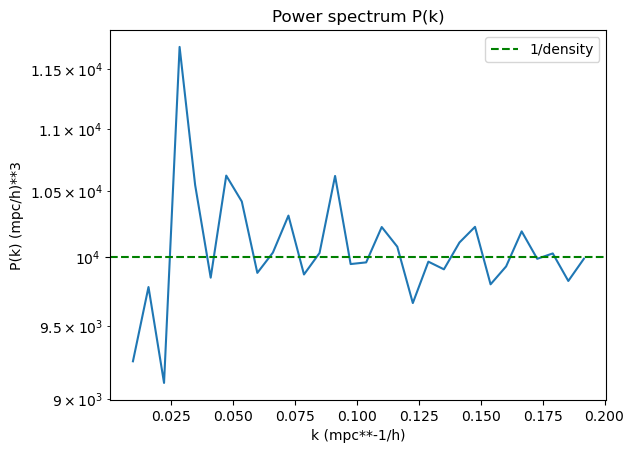

In [10]:
plt.semilogy(k_bins,pk_averaged,'-',markersize=5)
plt.axhline(1./density, color='green', linestyle='--', label='1/density')
plt.xlabel('k (mpc**-1/h)')
plt.ylabel('P(k) (mpc/h)**3')
plt.title('Power spectrum P(k)')
plt.legend()
plt.show()

NOTA BENE: prende dati random uniformi quindi il grafico cambia sempre se ri_runno

Riga orizzontale è lo shot noise, faccio osservazioni:
-se shot noise è un effetto limitato a scale piccole, nello spettro di pot shot noise influenza tutte le scale
-shot noise dipende da quante part ho osservato e come ho fatto survey-->segnale che vedo è la somma tra parte cosmologica e lo shot noise, devo bilanciare i due per avere un segnale totale buono

In [11]:
#http://www.magneticum.org/data.html#FULL_CATALOUGES   e poi Box2/hr e scarico snap_132, z=0.10114286 cluster


#nella pagina simulation fa vedere come sono fatte: sono box di 300 mpc circa, ma molte più particelle